<a href="https://colab.research.google.com/github/FreddyArceFernandez/AnalisisBullying/blob/main/Detecci%C3%B3n_de_Phishing_con_RNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===================================================
# 1. INSTALACIÓN Y CONFIGURACIÓN INICIAL
# ===================================================
!pip install scikit-learn pandas numpy tensorflow matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
import random
import string
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

print("✅ Librerías instaladas y cargadas.")

✅ Librerías instaladas y cargadas.


In [ ]:
# ===================================================
# 2. FUNCIONES PARA EXTRAER CARACTERÍSTICAS
# ===================================================

# Listas de TLDs y dominios de hosting/temporales (basados en el dataset)
SUSPICIOUS_TLDS = ['.pro', '.shop', '.sbs', '.top', '.lol', '.click', '.cfd', '.buzz',
                   '.site', '.online', '.cyou', '.xyz', '.ink', '.hair', '.skin',
                   '.garden', '.wiki', '.lat', '.casa', '.qpon', '.bond', '.beauty',
                   '.help', '.mom', '.live', '.app', '.dev', '.page', '.tech',
                   '.space', '.host', '.website', '.store', '.fun', '.cloud', '.icu']
FREE_HOSTING = ['weebly.com', 'wixstudio.com', 'vercel.app', 'netlify.app',
                'github.io', 'pages.dev', 'replit.app', 'wasmer.app',
                'duckdns.org', 'cpanel.site', 'bolt.host', 'onrender.com',
                'webflow.io', 'framer.app', 'framer.website', 'weeblysite.com',
                'godaddysites.com', 'typedream.app', 'square.site', 'myshopify.com',
                'softr.app', 'clickfunnels.com', 'zapier.app', 'ghost.io']

# Palabras clave comunes en phishing
SUSPICIOUS_WORDS = ['login', 'signin', 'secure', 'account', 'update', 'verify',
                    'confirm', 'payment', 'billing', 'customer', 'support',
                    'help', 'captcha', 'auth', 'validate', 'activate']

def extract_features(url):
    """
    Extrae un vector de características numéricas a partir de una URL.
    Los parámetros son los definidos en el análisis anterior.
    """
    features = {}

    try:
        parsed = urlparse(url)
        domain = parsed.netloc
        path = parsed.path
        query = parsed.query
        full_url = url

        # 1. Longitud de la URL
        features['length'] = len(full_url)

        # 2. Número de subdominios (puntos en el netloc)
        subdomains = domain.split('.')
        features['num_subdomains'] = len(subdomains) - 2  # restamos el dominio y TLD
        if features['num_subdomains'] < 0:
            features['num_subdomains'] = 0

        # 3. ¿El dominio principal contiene una marca conocida?
        # (simplificado: comprobamos si alguna palabra común está en el dominio)
        common_brands = ['amazon', 'paypal', 'microsoft', 'google', 'apple',
                         'facebook', 'twitter', 'instagram', 'linkedin',
                         'bradesco', 'allegro', 'dhl', 'fedex', 'trezor']
        domain_lower = domain.lower()
        brand_in_domain = any(brand in domain_lower for brand in common_brands)
        # ¿La marca está en el subdominio pero no en el dominio principal?
        # (lo simplificamos: si hay marca en cualquier parte del netloc)
        features['has_brand'] = 1 if brand_in_domain else 0

        # 4. TLD o dominio de bajo coste
        is_suspicious_tld = any(domain_lower.endswith(tld) for tld in SUSPICIOUS_TLDS)
        is_free_hosting = any(fh in domain_lower for fh in FREE_HOSTING)
        features['is_suspicious_domain'] = 1 if (is_suspicious_tld or is_free_hosting) else 0

        # 5. URL acortada (servicios comunes)
        shorteners = ['bit.ly', 'tinyurl', 'qrco.de', 'lnkd.in', 'goo.gl', 'ow.ly',
                      'rebrand.ly', 'cutt.ly', 'short.link', 'dub.sh', 'q-r.to']
        is_shortened = any(shortener in domain_lower for shortener in shorteners)
        features['is_shortened'] = 1 if is_shortened else 0

        # 6. Número de directorios en el path
        path_parts = [p for p in path.split('/') if p]
        features['num_dirs'] = len(path_parts)

        # 7. Palabras clave en el path
        path_lower = path.lower()
        suspicious_word_count = sum(1 for word in SUSPICIOUS_WORDS if word in path_lower)
        features['has_suspicious_words'] = 1 if suspicious_word_count >= 2 else 0

        # 8. Complejidad de los parámetros (query)
        num_params = len(query.split('&')) if query else 0
        long_value = any(len(v) > 30 for v in query.split('&')) if query else False
        features['complex_params'] = 1 if (num_params > 3 or long_value) else 0

        # 9. Presencia de '@'
        features['has_at'] = 1 if '@' in full_url else 0

        # 10. Uso de HTTPS (ya no es discriminante, lo incluimos por completitud)
        features['is_https'] = 1 if full_url.startswith('https://') else 0

    except Exception as e:
        # Si hay error al parsear, devolvemos valores por defecto
        print(f"Error al parsear {url}: {e}")
        features = {key: 0 for key in ['length', 'num_subdomains', 'has_brand',
                                       'is_suspicious_domain', 'is_shortened',
                                       'num_dirs', 'has_suspicious_words',
                                       'complex_params', 'has_at', 'is_https']}

    return list(features.values())

In [ ]:
# ===================================================
# 3. CARGA DE DATOS Y GENERACIÓN SINTÉTICA
# ===================================================

# Cargar el archivo CSV con las URLs de phishing
print("\n📂 Sube el archivo 'verified_online.csv'")
uploaded = files.upload()

# Leer el CSV
filename = list(uploaded.keys())[0]
df_phish = pd.read_csv(filename)

# Extraer las URLs de phishing
phish_urls = df_phish['url'].dropna().tolist()
print(f"✅ Se cargaron {len(phish_urls)} URLs de phishing.")

# --- Generar URLs legítimas sintéticas ---
def generate_legitimate_url(count=2000):
    domains = [
        'google.com', 'youtube.com', 'wikipedia.org', 'amazon.com',
        'microsoft.com', 'apple.com', 'facebook.com', 'twitter.com',
        'instagram.com', 'linkedin.com', 'reddit.com', 'github.com',
        'stackoverflow.com', 'netflix.com', 'spotify.com', 'adobe.com',
        'salesforce.com', 'oracle.com', 'cisco.com', 'intel.com'
    ]
    paths = ['/', '/about', '/contact', '/blog', '/products', '/services',
             '/login', '/signin', '/account', '/dashboard', '/settings',
             '/search', '/help', '/support', '/download', '/pricing']
    urls = []
    for _ in range(count):
        domain = random.choice(domains)
        path = random.choice(paths)
        # A veces añadir un parámetro simple
        if random.random() < 0.3:
            param = f"?id={random.randint(1000,9999)}"
        else:
            param = ""
        urls.append(f"https://{domain}{path}{param}")
    return urls

# --- Generar URLs sospechosas sintéticas ---
def generate_suspicious_url(count=2000):
    # Modificamos dominios legítimos o usamos características sospechosas
    base_domains = [
        'google', 'amazon', 'paypal', 'microsoft', 'apple', 'facebook', 'twitter'
    ]
    suspicious_paths = ['/verify-account', '/secure-login', '/update-payment',
                        '/confirm-identity', '/validate', '/captcha']
    suspicious_tlds = ['.pro', '.shop', '.click', '.xyz', '.top', '.sbs']
    urls = []
    for _ in range(count):
        base = random.choice(base_domains)
        # Añadir subdominios extraños o TLD sospechosos
        if random.random() < 0.5:
            # Subdominios excesivos
            sub = '.'.join([''.join(random.choices(string.ascii_lowercase, k=6)) for _ in range(random.randint(1, 3))])
            domain = f"{sub}.{base}{random.choice(suspicious_tlds)}"
        else:
            domain = f"{base}-{random.randint(100,999)}{random.choice(suspicious_tlds)}"
        path = random.choice(suspicious_paths)
        # Añadir parámetros largos a veces
        if random.random() < 0.4:
            params = f"?token={''.join(random.choices(string.ascii_letters + string.digits, k=40))}&r={random.randint(1,20)}"
        else:
            params = ""
        urls.append(f"https://{domain}{path}{params}")
    return urls

print("🔧 Generando datos sintéticos...")
legit_urls = generate_legitimate_url(2000)
susp_urls = generate_suspicious_url(2000)

# Mezclar con las URLs de phishing (limitamos a 2000 para balancear, pero puedes usar todas)
# Tomamos una muestra aleatoria de phishing para balancear
sample_phish = random.sample(phish_urls, min(2000, len(phish_urls)))

# Crear el DataFrame con las URLs y sus etiquetas
data = []
for url in legit_urls:
    data.append({'url': url, 'label': 0})  # 0 = Legítima
for url in susp_urls:
    data.append({'url': url, 'label': 1})  # 1 = Sospechosa
for url in sample_phish:
    data.append({'url': url, 'label': 2})  # 2 = Phishing

df = pd.DataFrame(data)
print(f"✅ Conjunto de datos creado: {len(df)} muestras.")
print(df['label'].value_counts().sort_index().to_dict())


📂 Sube el archivo 'verified_online.csv'


Saving verified_online.csv to verified_online (1).csv
✅ Se cargaron 65535 URLs de phishing.
🔧 Generando datos sintéticos...
✅ Conjunto de datos creado: 6000 muestras.
{0: 2000, 1: 2000, 2: 2000}


In [ ]:
# ===================================================
# 4. EXTRACCIÓN DE CARACTERÍSTICAS Y PREPROCESAMIENTO
# ===================================================

print("\n🔍 Extrayendo características de las URLs...")
feature_names = ['length', 'num_subdomains', 'has_brand', 'is_suspicious_domain',
                 'is_shortened', 'num_dirs', 'has_suspicious_words',
                 'complex_params', 'has_at', 'is_https']

X = np.array([extract_features(url) for url in df['url']])
y = df['label'].values

print(f"✅ Matriz de características: {X.shape}")

# Normalizar / escalar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} muestras, Prueba: {X_test.shape[0]} muestras.")


🔍 Extrayendo características de las URLs...
✅ Matriz de características: (6000, 10)
Entrenamiento: 4800 muestras, Prueba: 1200 muestras.


In [ ]:
# ===================================================
# 5. CONSTRUCCIÓN Y ENTRENAMIENTO DE LA RNA
# ===================================================

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 clases
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\n🧠 Arquitectura del modelo:")
model.summary()

# Entrenar el modelo
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


🧠 Arquitectura del modelo:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,883 (11.26 KB)

 Trainable params: 2,883 (11.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8216 - loss: 0.5565 - val_accuracy: 0.9688 - val_loss: 0.1637
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9620 - loss: 0.1689 - val_accuracy: 0.9688 - val_loss: 0.0998
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9685 - loss: 0.1254 - val_accuracy: 0.9740 - val_loss: 0.0857
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9714 - loss: 0.1077 - val_accuracy: 0.9729 - val_loss: 0.0840
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9714 - loss: 0.0984 - val_accuracy: 0.9729 - val_loss: 0.0769
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9711 - loss: 0.1006 - val_accuracy: 0.9750 - val_loss: 0.0757
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9737 - loss: 0.0946 - val_accuracy: 0.9760 - val_loss: 0.0749
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9755 - loss: 0.0928 - val_accuracy: 0.


✅ Precisión en el conjunto de prueba: 0.9858
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

📊 Matriz de Confusión:
[[399   0   1]
 [  0 400   0]
 [ 16   0 384]]

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

    Legítima       0.96      1.00      0.98       400
  Sospechosa       1.00      1.00      1.00       400
    Phishing       1.00      0.96      0.98       400

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



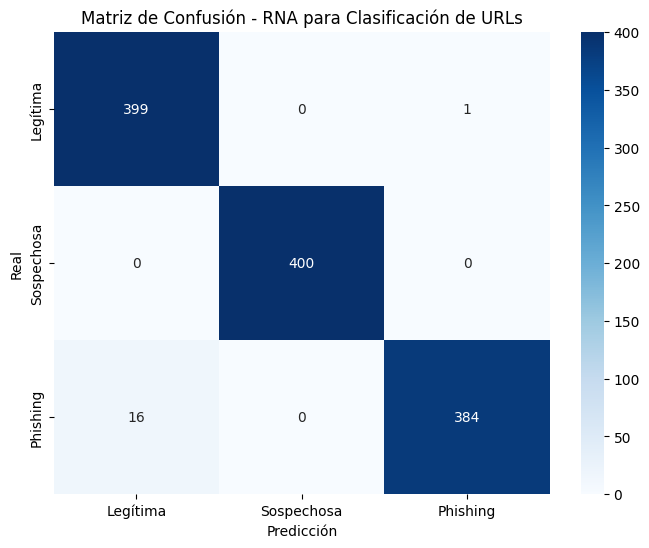

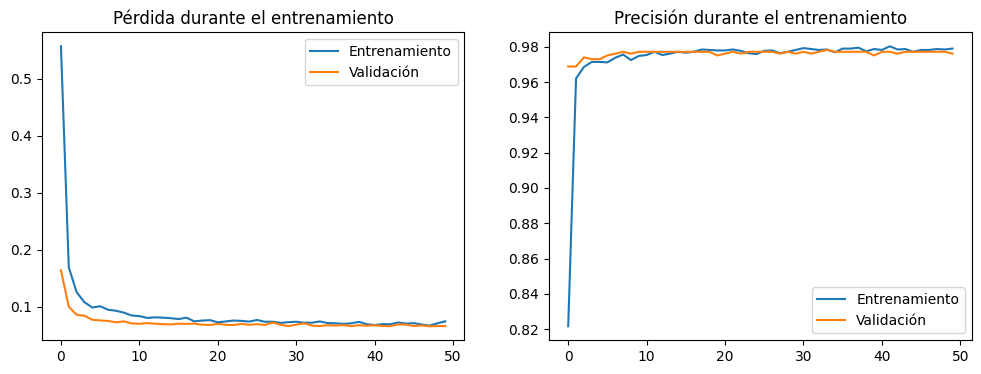

In [ ]:
# ===================================================
# 6. EVALUACIÓN DEL MODELO
# ===================================================

# Precisión en el conjunto de prueba
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Precisión en el conjunto de prueba: {test_acc:.4f}")

# Predicciones
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("\n📊 Matriz de Confusión:")
print(cm)

# Reporte de clasificación
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Legítima', 'Sospechosa', 'Phishing']))

# Visualización de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Sospechosa', 'Phishing'],
            yticklabels=['Legítima', 'Sospechosa', 'Phishing'])
plt.title('Matriz de Confusión - RNA para Clasificación de URLs')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

# Curvas de pérdida y precisión durante el entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión durante el entrenamiento')
plt.legend()
plt.show()

In [ ]:
# ===================================================
# 7. EJEMPLO DE CLASIFICACIÓN DE UNA NUEVA URL
# ===================================================

def classify_url(url):
    """Clasifica una URL en Legítima, Sospechosa o Phishing."""
    features = np.array([extract_features(url)])
    features_scaled = scaler.transform(features)
    prob = model.predict(features_scaled, verbose=0)
    class_idx = np.argmax(prob)
    classes = ['Legítima', 'Sospechosa', 'Phishing']
    return classes[class_idx], prob[0]

# Probemos con algunas URLs de ejemplo
print("\n🔍 Clasificación de URLs de ejemplo:")
test_urls = [
    "https://google.com/search?q=hola",
    "https://paypal-secure-verify.xyz/login.php?token=abc123",
    "https://amazon.com/gp/product/B08N5WRWNW",
    "https://login-support-microsoft.weebly.com/account-update.html",
    "https://amzaboprime025.pro/loading.php"
]

for url in test_urls:
    clase, probabilidad = classify_url(url)
    print(f"\nURL: {url}")
    print(f"Clasificación: {clase} (Probabilidades: Legítima={probabilidad[0]:.2f}, Sospechosa={probabilidad[1]:.2f}, Phishing={probabilidad[2]:.2f})")

print("\n✅ Código completado.")


🔍 Clasificación de URLs de ejemplo:

URL: https://google.com/search?q=hola
Clasificación: Legítima (Probabilidades: Legítima=1.00, Sospechosa=0.00, Phishing=0.00)

URL: https://paypal-secure-verify.xyz/login.php?token=abc123
Clasificación: Sospechosa (Probabilidades: Legítima=0.00, Sospechosa=0.60, Phishing=0.40)

URL: https://amazon.com/gp/product/B08N5WRWNW
Clasificación: Phishing (Probabilidades: Legítima=0.00, Sospechosa=0.00, Phishing=1.00)

URL: https://login-support-microsoft.weebly.com/account-update.html
Clasificación: Sospechosa (Probabilidades: Legítima=0.00, Sospechosa=1.00, Phishing=0.00)

URL: https://amzaboprime025.pro/loading.php
Clasificación: Phishing (Probabilidades: Legítima=0.00, Sospechosa=0.00, Phishing=1.00)

✅ Código completado.
